In [30]:
# load the data
import pandas as pd
import seaborn as sns
import seaborn as sns
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [31]:
penguins= sns.load_dataset('penguins', cache= False)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


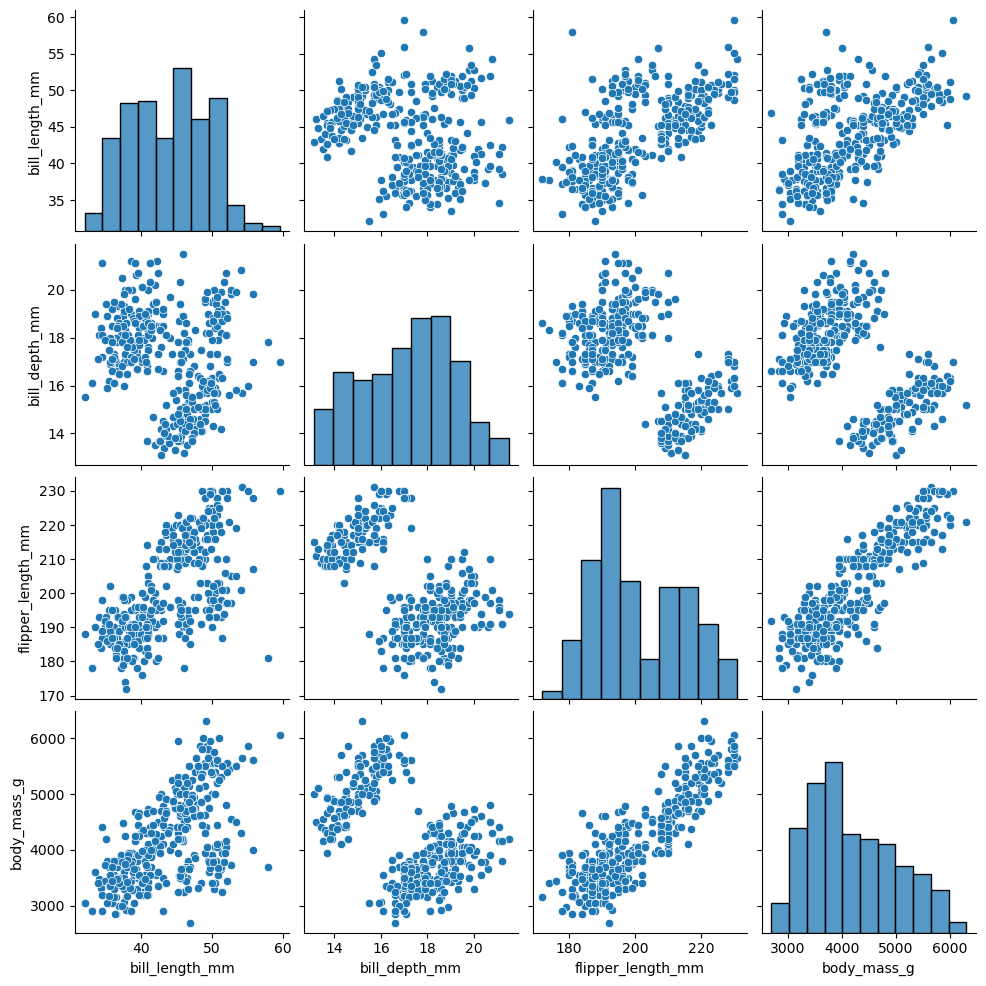

In [27]:
sns.pairplot(penguins)

In [32]:
penguins.shape

(344, 7)

There are 7 columns and 344 rows.  There appear to be missing data indicated by NaN. Sex, island and species are categorical variable the  rest of the variables are continous.

In [33]:
# Clean your data
# first create a subset
penguins= penguins[['body_mass_g', 'bill_length_mm', 'sex', 'species']]

# rename the columns
penguins.columns= ['body_mass_g', 'bill_length_mm', 'gender','species']

#Drop missing data
penguins.dropna(inplace= True)

# Reset Index
penguins.reset_index(inplace= True, drop= True)


In [35]:
penguins.head()

,body_mass_g,bill_length_mm,gender,species
0,3750.0,39.1,Male,Adelie
1,3800.0,39.5,Female,Adelie
2,3250.0,40.3,Female,Adelie
3,3450.0,36.7,Female,Adelie
4,3650.0,39.3,Male,Adelie


## Create a hold out sample

In [36]:
#subset_x and y variables
penguins_x= penguins[['bill_length_mm', 'gender', 'species']]
penguins_y= penguins[['body_mass_g']]

In [37]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(penguins_x, penguins_y,
                                                  test_size= 0.3, random_state= 42)

## Note: 
We have set the test_size variable to 0.3, which tells the function what proportion of the data should be in the holdout sample. Additionally, we have set the random_state variable equal to 42 for reproducibility. If you change the random_state, your holdout sample and training data sets will be different, so your model may perform differentl

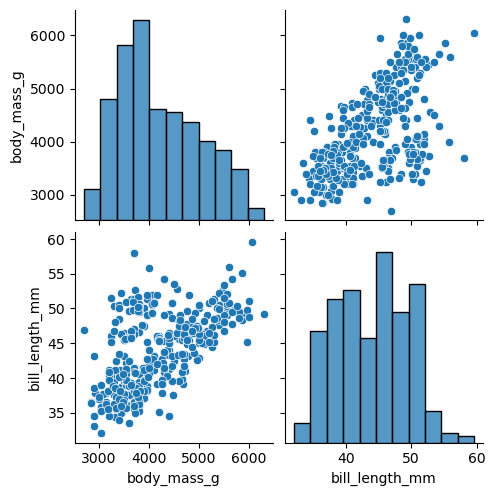

In [38]:
sns.pairplot(penguins)

In [42]:
# OLS Formula
ols_formula= "body_mass_g ~ bill_length_mm + C(gender) + C(species)"

In [43]:
#OLS data frame
ols_data= pd.concat([x_train, y_train], axis= 1)

# ols Object
OLS=ols(formula= ols_formula, data= ols_data)
model= OLS.fit()

In [44]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     322.6
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           1.31e-92
Time:                        13:27:10   Log-Likelihood:                -1671.7
No. Observations:                 233   AIC:                             3353.
Df Residuals:                     228   BIC:                             3371.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                2032.2111    354.087      5.739      0.000    1334.510    2729.913
C(gender)[T.Male]         528.9508     55.105      9.599      0.000     420.371     637.531
C(species)[T.Chinstrap]  -285.3865    106.339     -2.684      0.008    -494.920     -75.853
C(species)[T.Gentoo]     1081.6246     94.953     11.391      0.000     894.526    1268.723
bill_length_mm             35.5505      9.493      3.745      0.000      16.845      54.256
==============================================================================
Omnibus:                        0.339   Durbin-Watson:                   1.948
Prob(Omnibus):                  0.844   Jarque-Bera (JB):                0.436
Skew:                           0.084   Prob(JB):                        0.804
Kurtosis:                       2.871   Cond. No.                         798.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## According to the results
85% of the variation in body mass can be explained by the model. The model independent variables are statistically significant as shown 
by the P-values which is less than 0.05. 

## Coeffcicient interpretation

 ### C(gender)[T.Male]
 == the variable was encoded as 1== Male 0== Female. Meaning female is the reference point.
 If all variables are constant,  a male penguin body mass will be 529 grams more than a female penguin body mass
 ### G(Species)- Chinstrap and Gentoo 
 Given Chinstrap and Gentoo then Adele is the reference point
 Chinstrap Penguins have a body mass of about 285 grams less than the Adelien Penguin
 Gentoo Penguins have a body mass of 1081 grams more than Adelie Penguins
 ### Bill length mm
 if we compare two penguins who have the same characteristics, wewould expectthe penguin with the longer bill to have 35.55 grams more body mass than the one with shorter bill